In [2]:
#K-medias es un algoritmo de agrupamiento por particiones cuyo objetivo es separar los objetos
#en K conjuntos disjuntos minimizando la suma de distancias al cuadrado de los objetos
#de cada grupo. 
#Importamos los datos
import pandas as pd
url_datos = 'https://drive.google.com/uc?id=1OzVlp4RsT63W6d18_Zc5WmUonLXMDNL8'
mexpr = pd.read_csv(url_datos, delimiter='\t')
mexpr_toy = mexpr.iloc[0:49, 0:50] #Coger un conjunto pequeño de los datos

print(f"Dimensiones originales: {mexpr.shape}")
mexpr_toy.head()

Dimensiones originales: (1500, 473)


,TCGA-D9-A4Z6-06,TCGA-EE-A2MQ-06,TCGA-EE-A3AF-06,TCGA-ER-A19F-06,TCGA-EE-A2MF-06,TCGA-EE-A2MJ-06,TCGA-BF-AAP4-01,TCGA-D3-A8GM-06,TCGA-GN-A26A-06,TCGA-EB-A3XE-01,...,TCGA-BF-AAOX-01,TCGA-D9-A4Z5-01,TCGA-WE-A8K4-01,TCGA-D3-A8GK-06,TCGA-D3-A8GE-06,TCGA-FS-A4F2-06,TCGA-GN-A4U8-11,TCGA-GN-A8LL-06,TCGA-EE-A3JI-06,TCGA-EE-A20I-06
TYRP1,7.941545,2.750463,-5.566030,-4.907263,5.546815,7.036795,1.296667,8.453333,-4.295078,-2.822735,...,8.002252,-2.789695,1.109904,6.396219,-3.220495,-1.705895,-8.520540,6.068274,-8.134342,6.738309
RPS4Y1,3.475878,-9.252088,-8.781994,-1.866586,-7.544166,0.983460,3.230248,1.556010,-8.687076,-8.216183,...,2.055592,-2.148110,2.390604,3.739256,2.686378,-4.359921,3.940460,-4.851291,3.595815,2.730864
KRT6A,-2.734785,0.420073,0.026095,0.850417,-2.374815,3.097854,2.583622,-2.734785,-1.190053,13.664241,...,11.747622,-1.816628,-2.189904,-2.139473,-2.734785,-2.734785,-1.076003,-2.734785,-2.734785,-0.934828
XIST,-2.903056,8.320289,6.928525,-3.042341,9.475711,-3.487538,-2.690857,-3.487538,8.461294,6.168198,...,1.290439,-2.264424,-3.487538,-3.487538,-3.487538,9.536508,6.833770,7.086178,-2.925552,-1.214499
KRT14,-3.653679,-2.898792,-0.531967,0.375261,-0.798866,1.482611,1.573041,-3.232954,0.714726,13.313004,...,11.331971,-1.613172,-1.933576,-2.048090,-3.653679,-3.238245,-1.570908,3.679178,-3.653679,-1.546192


In [3]:
#Importamos librerias y definimos el algoritmo y sus parámetros
from sklearn.cluster import KMeans
from sklearn import metrics, preprocessing

datos = mexpr_toy.transpose()   #primero transponemos la matriz

#Estandarizamos (media=0, std=1)
scaler = preprocessing.StandardScaler()
datos_scaled=pd.DataFrame(
    scaler.fit_transform(datos),
    index=datos.index,
    columns=datos.columns
)
print(f"Forma de los datos para clustering: {datos_scaled.shape}")
print("(filas=muestras, columnas=genes)")

Forma de los datos para clustering: (50, 49)
(filas=muestras, columnas=genes)


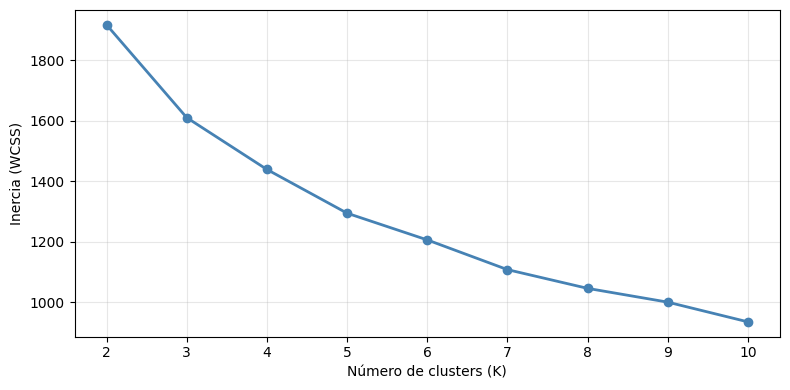

In [4]:
#Búsqueda del K óptimo: método del codo
import matplotlib.pyplot as plt
inercias = []
rango_k = range(2,11)
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(datos_scaled)
    inercias.append(km.inertia_)

#Gráfico del codo
plt.figure(figsize=(8, 4))
plt.plot(rango_k, inercias, marker='o', linewidth=2, color='steelblue')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia (WCSS)')
plt.xticks(rango_k)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Primera forma de buscar el K óptimo. La gráfica superior muestra el método del codo, cuanta mayor sea la inercia (WCSS) más óptimo es el número de clusters. En este caso el número de clusters óptimo es 2. Sin embargo, lo podemos comprobar haciendo el Índice Silhouette

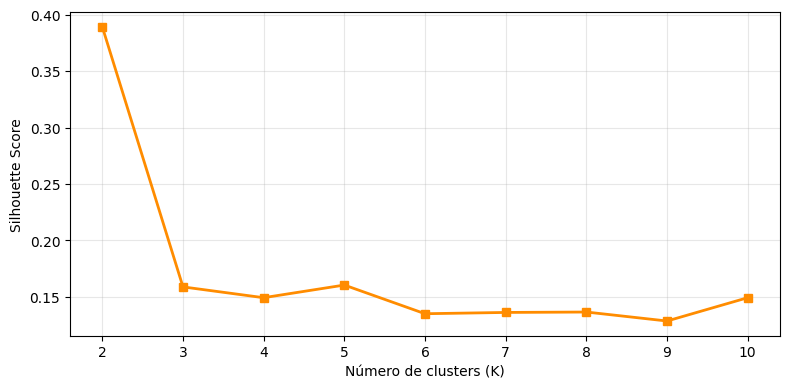

K óptimo según Silhouette: 2 (score = 0.389)


In [5]:
#Búsqueda del K óptimo: Índice Silhouette

silhouettes = []

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(datos_scaled)
    score = metrics.silhouette_score(datos_scaled, labels)
    silhouettes.append(score)

#Gráfico silhouette
plt.figure(figsize=(8,4))
plt.plot(rango_k, silhouettes, marker='s', linewidth=2, color='darkorange')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(rango_k)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

k_optimo = rango_k[silhouettes.index(max(silhouettes))]
print(f"K óptimo según Silhouette: {k_optimo} (score = {max(silhouettes):.3f})")

Otra forma de buscar el K óptimo. En la gráfica superior, se puede visualizar la puntuación del índice de silhouette en función del número de clusters. Cuanto mayor es el score (parte superior de la gráfica) más óptimo es la K.

In [6]:
#Clustering final con el K óptimo
k_means_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
cluster_predict = k_means_final.fit_predict(datos_scaled)

clusters = pd.DataFrame(cluster_predict, index=datos_scaled.index, columns=['cluster'])

print("Tamaño de cada cluster:")
print(clusters['cluster'].value_counts().sort_index())


Tamaño de cada cluster:
cluster
0    46
1     4
Name: count, dtype: int64


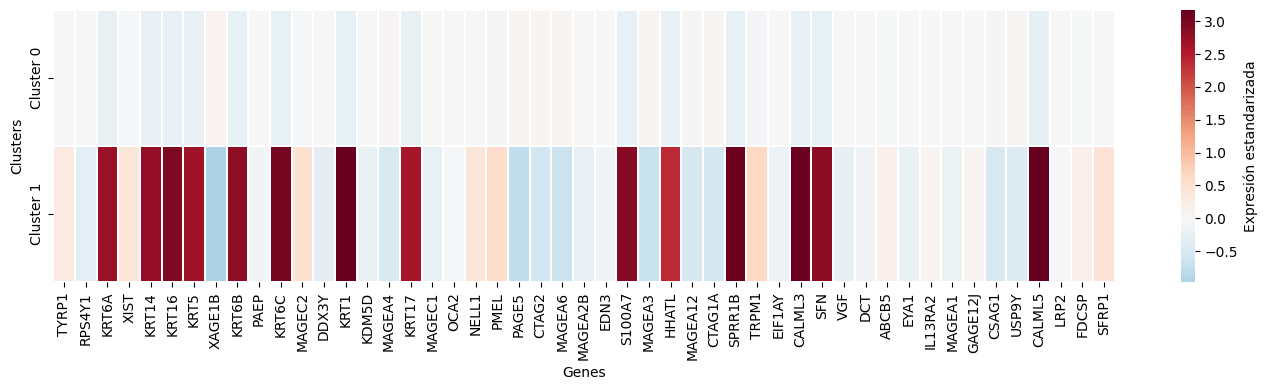

In [7]:
#Heatmap de centroides
import seaborn as sns
centers = pd.DataFrame(k_means_final.cluster_centers_, columns=datos_scaled.columns)
centers.index = [f'Cluster {i}' for i in centers.index]

plt.figure(figsize=(14,4))
sns.heatmap(centers, cmap='RdBu_r',
            center=0, linewidths=0.3,
            annot=False, yticklabels=True,
            xticklabels=True,
            cbar_kws={'label':'Expresión estandarizada'}
)
plt.xlabel('Genes')
plt.ylabel('Clusters')
plt.tight_layout()
plt.show()

In [8]:
#Índices de bondad del clustering final
sil = metrics.silhouette_score(datos_scaled, cluster_predict)
ch = metrics.calinski_harabasz_score(datos_scaled, cluster_predict)
db = metrics.davies_bouldin_score(datos_scaled, cluster_predict)

print("=== Bondad del Clustering ===")
print(f" Silhouette Score   : {sil:.4f}")
print(f" Calinski-Harabasz  : {ch:.2f}")
print(f" Davies-Bouldin     : {db:.4f}")

=== Bondad del Clustering ===
 Silhouette Score   : 0.3892
 Calinski-Harabasz  : 13.33
 Davies-Bouldin     : 0.9405


Silhouette Score: El rango es de [-1,1], por lo que un valor positivo es buen indicio. Los clusters tienen cierta separación real pero hay algo de solapamiento. Para datos de expresión génica es habitual, ya que el ruido biológico hace difícil que haya una separación limpia.

Calinski-Harabasz: El rango es de [0,∞), por lo que se interpreta comparando entre distintos K. Este índice es el que más sufre con un dataset pequeño, podemos probar a dar más espacio.

Davies-Bouldin: el rango ideal es [0,∞), donde a menor valor mejor es el resultado.

Al aumentar el número de muestras - [0:49, 0:19] a [0:49, 0:50], el índice C-H aumenta significativamente (x3) y el Silhouette se mantiene estable, lo que es buena señal. Sin embargo, el índice D-B aumenta también, indicando que los clusters se volvieron menos compactos internamente en relación a su separación.

In [9]:
#Aunque el K óptimo sigue siendo 2, podemos probar a hacer una tabla comparativa con más índices.
resultados = []

for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(datos_scaled)
    resultados.append({
        'K': k,
        'Silhouette': round(metrics.silhouette_score(datos_scaled, labels), 4),
        'Calinski-Harabasz': round(metrics.calinski_harabasz_score(datos_scaled, labels), 2),
        'Davies-Bouldin': round(metrics.davies_bouldin_score(datos_scaled, labels), 4)
    })

pd.DataFrame(resultados).set_index('K')

,Silhouette,Calinski-Harabasz,Davies-Bouldin
K,,,
2,0.3892,13.33,0.9405
3,0.1589,12.25,1.7207
4,0.1494,10.77,1.6123


Vemos que, efectivamente, K=2 es la mejor opción, posicionandose con los 3 mejores índices.

In [10]:
#Vamos a preparar ahora una visualización PCA
#Reducción de dimensionalidad con PCA
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
import numpy as np

pca = PCA(n_components=2)
datos_pca = pca.fit_transform(datos_scaled)

varianza_explicada = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {varianza_explicada[0]*100:.1f}%")
print(f"Varianza explicada por PC2: {varianza_explicada[1]*100:.1f}%")
print(f"Varianza total explicada: {sum(varianza_explicada)*100:.1f}%")

Varianza explicada por PC1: 26.4%
Varianza explicada por PC2: 15.4%
Varianza total explicada: 41.8%


In [11]:
#Clustering final con K=2 sobre datos escalados
k_means_final = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_predict = k_means_final.fit_predict(datos_scaled)

clusters = pd.DataFrame(cluster_predict, index=datos_scaled.index, columns=['cluster'])
print("Tamaño de cada cluster:")
print(clusters['cluster'].value_counts().sort_index())

Tamaño de cada cluster:
cluster
0    46
1     4
Name: count, dtype: int64


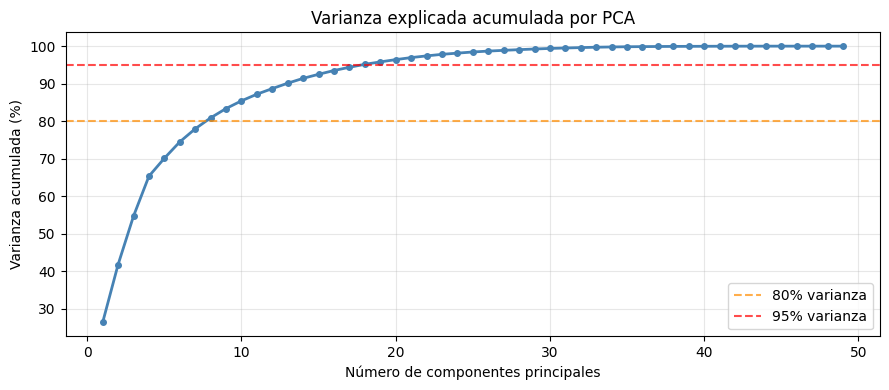

PCs necesarios para explicar el 80% de la varianza: 8
PCs necesarios para explicar el 95% de la varianza: 18


In [16]:
#Varianza acumulada - Cuántos PCs necesitamos?
pca_full = PCA()
pca_full.fit(datos_scaled)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_) * 100

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada,
         marker='o', linewidth=2, color='steelblue', markersize=4)
plt.axhline(y=80, color='darkorange', linestyle='--', alpha=0.7, label='80% varianza')
plt.axhline(y=95, color='red', linestyle='--', alpha=0.7, label='95% varianza')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza acumulada (%)')
plt.title('Varianza explicada acumulada por PCA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ¿Cuántos PCs hacen falta para llegar al 80% y 95%?
pc_80 = next(i+1 for i, v in enumerate(varianza_acumulada) if v >= 80)
pc_95 = next(i+1 for i, v in enumerate(varianza_acumulada) if v >= 95)
print(f"PCs necesarios para explicar el 80% de la varianza: {pc_80}")
print(f"PCs necesarios para explicar el 95% de la varianza: {pc_95}")

Esto nos indica que necesitamos 8 dimensiones para visualizar el 80% y 18 para el 95%. Esto quiero decir que la varianza está muy repartida entre muchos genes y por tanto no hay ninguna dirección dominante clara. 

A partir de aquí hay dos opciones, hacer un PCA antes del clustering para trabajar con 8 PCs (80% varianza), por lo que se traaja en un espacio más limpio o continuar con el análisis actual, en el que tenemos el clustering en full-space. En este último caso, aceptamos que la visualización 3D es orientativa y le damos importancia a interpretar los resultados biológicamente.

Varianza explicada acumulada con 3 PCs: 54.7%


c:\Users\Enri\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


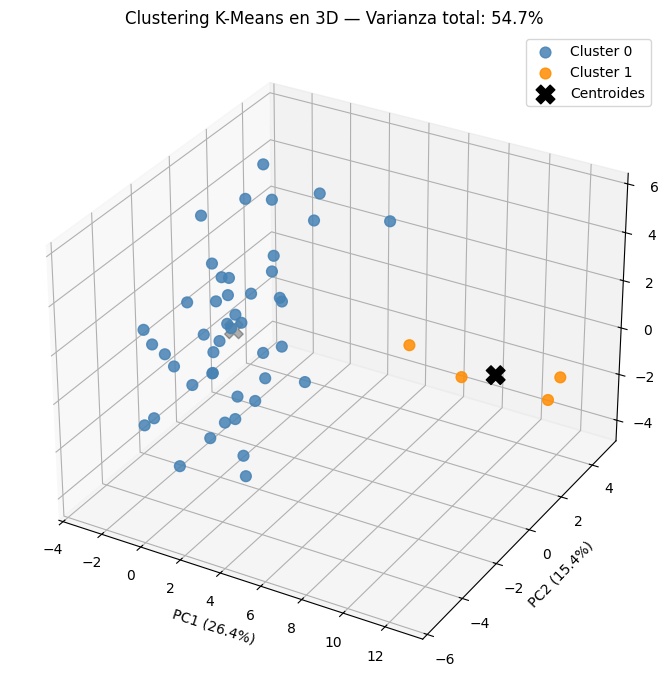

In [15]:
#Visualizaación PCA con clusters
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3)
datos_pca3 = pca3.fit_transform(datos_scaled)
var3 = pca3.explained_variance_ratio_

print(f"Varianza explicada acumulada con 3 PCs: {sum(var3)*100:.1f}%")

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for i in range(2):
    mask = cluster_predict == i
    ax.scatter(
        datos_pca3[mask, 0],
        datos_pca3[mask, 1],
        datos_pca3[mask, 2],
        c=colores[i],
        label=etiquetas[i],
        s=60, alpha=0.85
    )

# Centroides en 3D
centroides_pca3 = pca3.transform(k_means_final.cluster_centers_)
ax.scatter(
    centroides_pca3[:, 0],
    centroides_pca3[:, 1],
    centroides_pca3[:, 2],
    c='black', marker='X', s=180, zorder=5, label='Centroides'
)

ax.set_xlabel(f'PC1 ({var3[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var3[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({var3[2]*100:.1f}%)')
ax.set_title(f'Clustering K-Means en 3D — Varianza total: {sum(var3)*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.show()
